# Titanic Project

می‌خوایم عواملی که روی زنده موندن مسافرهای تایتانیک تأثیر داشته رو بررسی کنیم و پیش‌بینی کنیم چه افرادی شانس زنده موندن دارن. در واقع هدف ما ساخت مدلیه که بتونه این پیش‌بینی رو انجام بده.


In [2]:
#کتابخانه های استفاده شده
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#برای نمودار ها
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [3]:
#خواندن دیتاست
df = pd.read_csv("titanic.csv")

In [4]:
#دیدن۱۰ ردیف اول
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [5]:
#تعداد ردیف و ستون
df.shape

(891, 12)

In [6]:
# نوع داده ها و تعداد NANها
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
#آمارهای میانگین، میانه ،....
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
#دیدن۱۰ردیف اخر
df.tail(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
881,882,0,3,"Markun, Mr. Johann",male,33.0,0,0,349257,7.8958,NaN,S
882,883,0,3,"Dahlberg, Miss. Gerda Ulrika",female,22.0,0,0,7552,10.5167,NaN,S
883,884,0,2,"Banfield, Mr. Frederick James",male,28.0,0,0,C.A./SOTON 34068,10.5000,NaN,S
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.7500,NaN,Q


In [9]:
#ستون هایی که مقدار خالی دارن
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

Cabin       687
Age         177
Embarked      2
dtype: int64

In [10]:
#تعداد ردیف های تکراری
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [11]:
#تعداد و درصد مسافر ها براساس وضعیت
survival_counts = df["Survived"].value_counts()
print(survival_counts)

print()

survival_percentage = df["Survived"].value_counts(normalize=True) * 100
print(survival_percentage)

Survived
0    549
1    342
Name: count, dtype: int64

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


In [12]:
#ستون های غیر عددی
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    print(f"\n{col}: {df[col].nunique()} unique")
    print(df[col].unique()[:8])


Name: 891 unique
['Braund, Mr. Owen Harris'
 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)'
 'Heikkinen, Miss. Laina' 'Futrelle, Mrs. Jacques Heath (Lily May Peel)'
 'Allen, Mr. William Henry' 'Moran, Mr. James' 'McCarthy, Mr. Timothy J'
 'Palsson, Master. Gosta Leonard']

Sex: 2 unique
['male' 'female']

Ticket: 681 unique
['A/5 21171' 'PC 17599' 'STON/O2. 3101282' '113803' '373450' '330877'
 '17463' '349909']

Cabin: 147 unique
[nan 'C85' 'C123' 'E46' 'G6' 'C103' 'D56' 'A6']

Embarked: 3 unique
['S' 'C' 'Q' nan]


# بررسی اولیه من:

داده‌ها ۸۹۱ ردیف و ۱۲ ستون دارن
مقدار صفر و یک داره، یعنی طبقه‌ بندی دودویی(۰=مرده و ۱=زنده)
(سه تا ستون خالی دارن( کابین، سن و محل سوار شدن
کابین بیشتر از ۷۰ درصد خالیه، به درد نمی‌خوره
اسم، شماره بلیط و شناسه مسافر هم اطلاعات مفیدی ندارن
متعادل نیستن ۳۸ درصد زنده ، ۶۲ درصد مرده

#تعداد نفراتی که زنده ماندن یا زنده نماندن با نمودار
sns.countplot(data=df, x="Survived")
plt.title("Survived vs Not Survived")
plt.show()

حدود ۳۸٪ مسافرها زنده موندن. کلاس‌ها متعادل نیستن و موقع ارزیابی
مدل این نکته رو در نظر می‌گیریم.

# Class 1 — NumPy

کار با آرایه و محاسبات عددی

In [17]:
#ساختن ارایه
a = np.array([22, 25, 30, 35, 40])

print("Array:", a)
print("Shape:", a.shape)
print("Size:", a.size)
print("Dtype:", a.dtype)

Array: [22 25 30 35 40]
Shape: (5,)
Size: 5
Dtype: int32


In [18]:
#میانگین و میانه و ... روی این ارایه
print("Mean:", np.mean(a))
print("Median:", np.median(a))
print("Min:", np.min(a))
print("Max:", np.max(a))
print("Std:", np.std(a))

Mean: 30.4
Median: 30.0
Min: 22
Max: 40
Std: 6.529931086925803


In [19]:
#تبدیل ستون سن به numpy
age = df["Age"].to_numpy()
age[:20]

array([22., 38., 26., 35., 35., nan, 54.,  2., 27., 14.,  4., 58., 20.,
       39., 14., 55.,  2., nan, 31., nan])

In [20]:
#تعداد ستون های خالی سن
print("Missing ages:", np.isnan(age).sum())
print("Total ages:", len(age))

Missing ages: 177
Total ages: 891


In [21]:
#حذف NaN ها
age_clean = age[~np.isnan(age)]

print("Valid ages:", len(age_clean))
print("Mean:", np.mean(age_clean))
print("Median:", np.median(age_clean))
print("Std:", np.std(age_clean))

Valid ages: 714
Mean: 29.69911764705882
Median: 28.0
Std: 14.516321150817316


In [22]:
#مسافرهای زیر ۱۸ سال
kids = age_clean[age_clean < 18]
print("Under 18:", len(kids))

Under 18: 113


In [23]:
#مسافر های بین ۱۸تا۳۰ سال
young = age_clean[(age_clean >= 18) & (age_clean <= 30)]
print("Between 18 and 30:", len(young))

Between 18 and 30: 296


In [24]:
#مسافر های بالای۵۰ سال
old = age_clean[age_clean > 50]
print("Above 50:", len(old))
print(old)

Above 50: 64
[54.  58.  55.  66.  65.  59.  71.  70.5 54.  51.  55.5 51.  61.  56.
 58.  51.  59.  54.  62.  52.  58.  63.  65.  54.  61.  60.  51.  64.
 52.  65.  56.  63.  58.  55.  71.  54.  54.  64.  62.  62.  53.  54.
 60.  52.  61.  57.  80.  51.  56.  58.  70.  60.  60.  52.  52.  70.
 51.  57.  54.  52.  62.  74.  51.  56. ]


In [25]:
# همین کار روی Fare
fare = df["Fare"].to_numpy()

print("Mean fare:", np.mean(fare))
print("Max fare:", np.max(fare))
print("Fares above 100:", len(fare[fare > 100]))

Mean fare: 32.204207968574636
Max fare: 512.3292
Fares above 100: 53


با NumPy آماره‌های Age و Fare حساب شد. NaN ها قبل از محاسبه حذف شدن چون `np.mean` روی آرایه‌ ی دارای NaN نتیجه‌ی اشتباه می‌ده.

# Class 2 — Pandas

انتخاب، فیلتر، مرتب‌ سازی و گروهبندی

In [28]:
#دیدن۱۰تا ردیف اول توی ستون اسم و جنسیت و سن و وضعیت زنده ماندنشون
df[["Name", "Sex", "Age", "Survived"]].head(10)

,Name,Sex,Age,Survived
0,"Braund, Mr. Owen Harris",male,22.0,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1
2,"Heikkinen, Miss. Laina",female,26.0,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1
4,"Allen, Mr. William Henry",male,35.0,0
5,"Moran, Mr. James",male,NaN,0
6,"McCarthy, Mr. Timothy J",male,54.0,0
7,"Palsson, Master. Gosta Leonard",male,2.0,0
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,1
9,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1


In [29]:
#فقط مسافرهای فرست کلاس
first_class = df[df["Pclass"] == 1]
print("First class:", len(first_class))
first_class[["Name", "Fare", "Survived"]].head()

First class: 216


,Name,Fare,Survived
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",71.2833,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",53.1000,1
6,"McCarthy, Mr. Timothy J",51.8625,0
11,"Bonnell, Miss. Elizabeth",26.5500,1
23,"Sloper, Mr. William Thompson",35.5000,1


In [30]:
#زن ها و زنده مانده ها
women = df[df["Sex"] == "female"]
survivors = df[df["Survived"] == 1]

print("Women:", len(women))
print("Survivors:", len(survivors))

Women: 314
Survivors: 342


In [31]:
#زن هایی که زنده موندن
women_survived = df[(df["Sex"] == "female") & (df["Survived"] == 1)]
print("Women survivors:", len(women_survived))
women_survived[["Name", "Age", "Pclass"]].head()

Women survivors: 233


,Name,Age,Pclass
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1
2,"Heikkinen, Miss. Laina",26.0,3
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",27.0,3
9,"Nasser, Mrs. Nicholas (Adele Achem)",14.0,2


In [32]:
#گرون ترین بلیط ها
df.sort_values("Fare", ascending=False)[["Name", "Fare", "Pclass"]].head(10)

,Name,Fare,Pclass
258,"Ward, Miss. Anna",512.3292,1
737,"Lesurer, Mr. Gustave J",512.3292,1
679,"Cardeza, Mr. Thomas Drake Martinez",512.3292,1
88,"Fortune, Miss. Mabel Helen",263.0000,1
27,"Fortune, Mr. Charles Alexander",263.0000,1
341,"Fortune, Miss. Alice Elizabeth",263.0000,1
438,"Fortune, Mr. Mark",263.0000,1
311,"Ryerson, Miss. Emily Borie",262.3750,1
742,"Ryerson, Miss. Susan Parker ""Suzette""",262.3750,1
118,"Baxter, Mr. Quigg Edmond",247.5208,1


In [33]:
#پیر ترین مسافر ها
df.sort_values("Age", ascending=False)[["Name", "Age", "Survived"]].head(10)

,Name,Age,Survived
630,"Barkworth, Mr. Algernon Henry Wilson",80.0,1
851,"Svensson, Mr. Johan",74.0,0
493,"Artagaveytia, Mr. Ramon",71.0,0
96,"Goldschmidt, Mr. George B",71.0,0
116,"Connors, Mr. Patrick",70.5,0
672,"Mitchell, Mr. Henry Michael",70.0,0
745,"Crosby, Capt. Edward Gifford",70.0,0
33,"Wheadon, Mr. Edward H",66.0,0
54,"Ostby, Mr. Engelhart Cornelius",65.0,0
280,"Duane, Mr. Frank",65.0,0


In [34]:
#تعداد اعضای خانواده
df["FamilyMembers"] = df["SibSp"] + df["Parch"] + 1
df[["SibSp", "Parch", "FamilyMembers"]].head()

,SibSp,Parch,FamilyMembers
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [35]:
# هزینه‌ی بلیط به ازای هر نفر
df["Fare_Per_Person"] = df["Fare"] / df["FamilyMembers"]
df[["Fare", "FamilyMembers", "Fare_Per_Person"]].head()

,Fare,FamilyMembers,Fare_Per_Person
0,7.2500,2,3.62500
1,71.2833,2,35.64165
2,7.9250,1,7.92500
3,53.1000,2,26.55000
4,8.0500,1,8.05000


In [36]:
#گروهبندی سنی
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 18, 30, 50, 100],
    labels=["Child", "Young", "Adult", "Senior"]
)
df[["Age", "AgeGroup"]].head(10)

,Age,AgeGroup
0,22.0,Young
1,38.0,Adult
2,26.0,Young
3,35.0,Adult
4,35.0,Adult
5,NaN,NaN
6,54.0,Senior
7,2.0,Child
8,27.0,Young
9,14.0,Child


In [37]:
#تعداد براساس جنسیت
df.groupby("Sex").size()

Sex
female    314
male      577
dtype: int64

In [38]:
#میانگین سن بر اساس جنست
df.groupby("Sex")["Age"].mean()

Sex
female    27.915709
male      30.726645
Name: Age, dtype: float64

In [39]:
#کسانی که زنده موندن براساس جنسیت
df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [40]:
#کسانی که زنده موندن براساس کلاس
df.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [41]:
#خلاصه تعداد، میانگین سن و....
summary = df.groupby("Pclass").agg(
    Passengers=("PassengerId", "count"),
    AvgAge=("Age", "mean"),
    AvgFare=("Fare", "mean"),
    SurvivalRate=("Survived", "mean")
)
summary

,Passengers,AvgAge,AvgFare,SurvivalRate
Pclass,,,,
1,216,38.233441,84.154687,0.629630
2,184,29.877630,20.662183,0.472826
3,491,25.140620,13.675550,0.242363


In [42]:
#ترکیب جنسیت و کلاس
df.groupby(["Sex", "Pclass"])["Survived"].mean()

Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64

زن‌های کلاس ۱ بالاترین نرخ بقا رو داشتن، مردهای کلاس ۳ کمترین. جنسیت و کلاس بلیط دو عامل کلیدی تأثیرگذار بودن

# Class 3 — Matplotlib & Seaborn

استفاده از نمودارهای هیستوگرام،میله ای و ماتریس

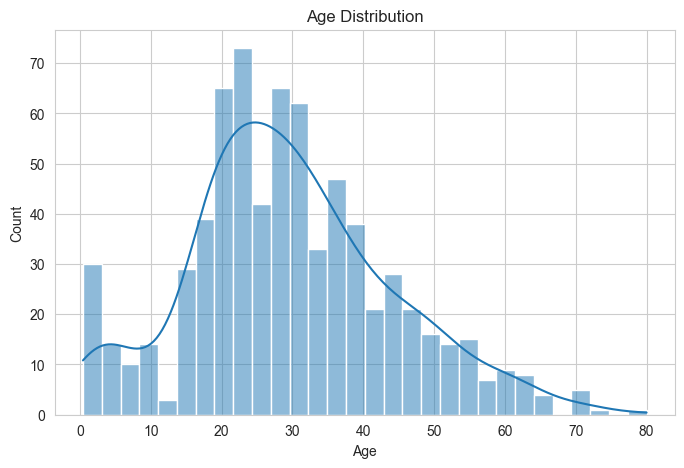

In [45]:
#وضعیت سن با نمودار
sns.histplot(df["Age"].dropna(), bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

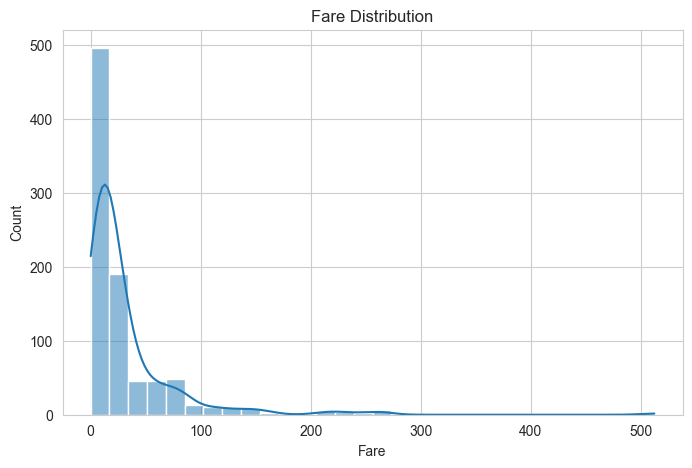

In [46]:
#هزینه بلیط با نمودار
sns.histplot(df["Fare"], bins=30, kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.show()

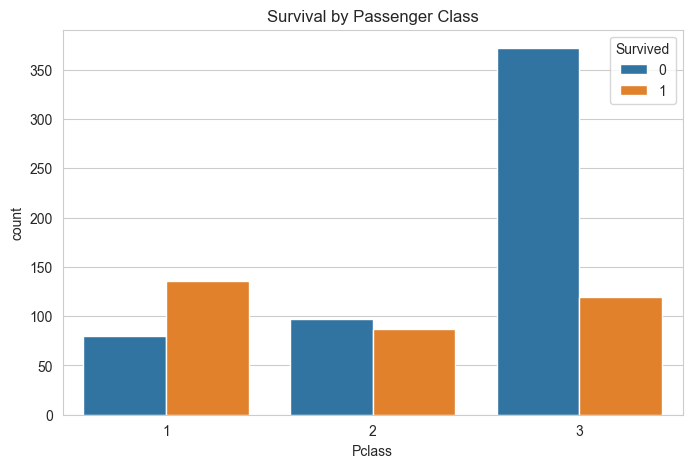

In [47]:
#وضعیت افراد زنده بر اساس کلاس با نمودار
sns.countplot(data=df, x="Pclass", hue="Survived")
plt.title("Survival by Passenger Class")
plt.show()

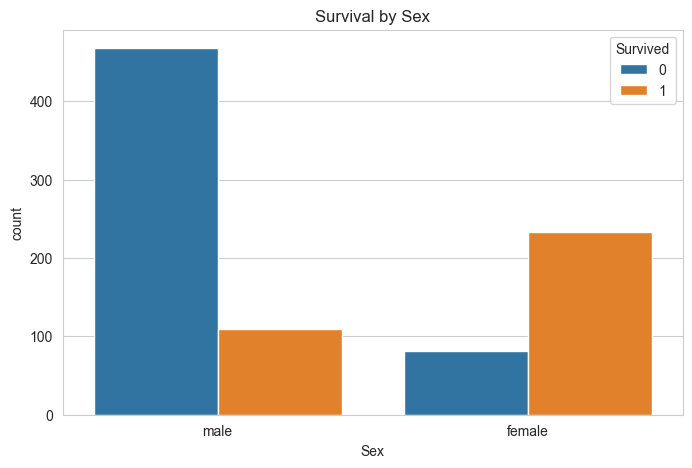

In [48]:
#وضعیت افراد زنده بر اساس جنسیت با نمودار
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Survival by Sex")
plt.show()

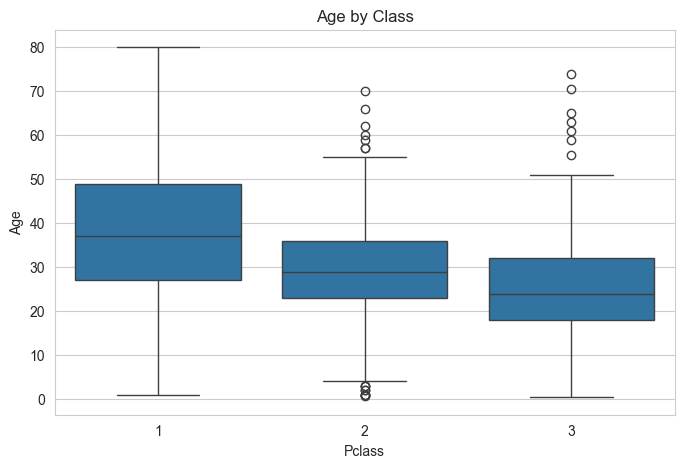

In [49]:
#پراکندگی سن در هر کلاس
sns.boxplot(data=df, x="Pclass", y="Age")
plt.title("Age by Class")
plt.show()

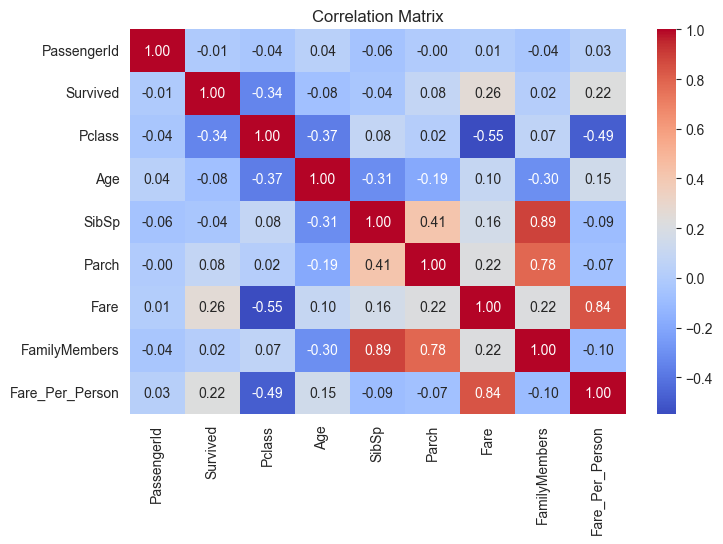

In [50]:
#ماتریس همبستگی متغیر های عددی
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

کلاس بالاتر یعنی بلیط گرون‌ تر، سن توزیع نرمال داره و
Fare چوله‌ هست

# Class 4 — Data Preprocessing

پر کردن مقادیر خالی، حذف ستونهای اضافه و تبدیل متن به عدد

In [53]:
#چک کردن خالی ها
df.isnull().sum()

PassengerId          0
Survived             0
Pclass               0
Name                 0
Sex                  0
Age                177
SibSp                0
Parch                0
Ticket               0
Fare                 0
Cabin              687
Embarked             2
FamilyMembers        0
Fare_Per_Person      0
AgeGroup           177
dtype: int64

In [54]:
#پرکردن مقادیری که خالی بودن
df["Age"] = df["Age"].fillna(df["Age"].median())

#پر کردن  با بیشترین تکرار در Embarked
if "Embarked" in df.columns:
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
    print("Embarked filled with mode.")
else:
    print("Embarked already encoded - skipping.")
#NaNهای باقی مونده
print("Remaining NaN (before drop):", df.isnull().sum().sum())

Embarked filled with mode.
Remaining NaN (before drop): 864


In [55]:
#حذف ستونهایی که نمیخوایم
df = df.drop(columns=["Cabin", "Ticket", "Name", "PassengerId", "AgeGroup"], errors="ignore")
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'FamilyMembers', 'Fare_Per_Person'],
      dtype='object')

In [56]:
#تبدیل این۲ستون از رشته ای به عددی
cols_to_encode = [c for c in ["Sex", "Embarked"] if c in df.columns]

#برای جلوگیری از همبستگیی بین ستونها
df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilyMembers,Fare_Per_Person,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,2,3.62500,True,False,True
1,1,1,38.0,1,0,71.2833,2,35.64165,False,False,False
2,1,3,26.0,0,0,7.9250,1,7.92500,False,False,True
3,1,1,35.0,1,0,53.1000,2,26.55000,False,False,True
4,0,3,35.0,0,0,8.0500,1,8.05000,True,False,True


In [57]:
#شکل و نوع داده هامون
print("Shape:", df.shape)
print()
print(df.dtypes)

Shape: (891, 11)

Survived             int64
Pclass               int64
Age                float64
SibSp                int64
Parch                int64
Fare               float64
FamilyMembers        int64
Fare_Per_Person    float64
Sex_male              bool
Embarked_Q            bool
Embarked_S            bool
dtype: object


In [58]:
#چک کردن ستون ها که مطمين بشم عددی هستن
non_num = df.select_dtypes(include="object").columns.tolist()
print("Non-numeric columns:", non_num)

if len(non_num) == 0:
    print( "همه ستون‌ها عددی‌ هستن" )
else:
    print( "این ستون‌ها هنوز رشته‌ ای هستن:", non_num )

Non-numeric columns: []
همه ستون‌ها عددی‌ هستن


# Class 5 — Train/Test Split

داده رو به ۲ بخش آموزش و تست تقسیم می‌کنیم واموزش و ازمون....

In [60]:
from sklearn.model_selection import train_test_split
#جدا کردن لیبل از ویژگی ها
X = df.drop(columns=["Survived"])
y = df["Survived"]
#تقسیم داده های اموزشی و امتحانی
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (712, 10)
X_test : (179, 10)
y_train: (712,)
y_test : (179,)


# Class 6 — Logistic Regression

مدل خطی برای طبقه‌ بندی دودویی 
ساده و سریعه و به مقیاس‌ بندی 
حساس نیس،.

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
#ساختن و اموزش مدل
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
#پیش بینی روی داده تست
pred_lr = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_lr))
print()
print(classification_report(y_test, pred_lr))

Accuracy: 0.7988826815642458

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       110
           1       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179



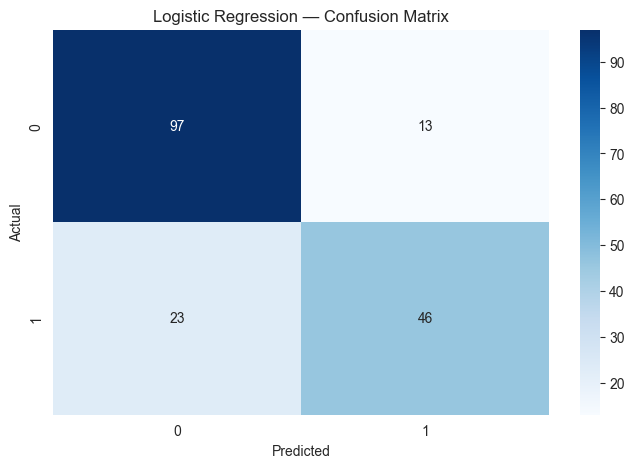

In [63]:
#ماتریس درهم ریختگی
sns.heatmap(confusion_matrix(y_test, pred_lr),
            annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Class 7 — KNN

KNN به فاصله حساسه
داده رو هم‌ قیاس میکنیم

In [65]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [66]:
#ساخت و اموزش مدل
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_sc, y_train)

pred_knn = knn.predict(X_test_sc)

print("Accuracy:", accuracy_score(y_test, pred_knn))
print()
print(classification_report(y_test, pred_knn))

Accuracy: 0.7932960893854749

              precision    recall  f1-score   support

           0       0.82      0.85      0.84       110
           1       0.75      0.70      0.72        69

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



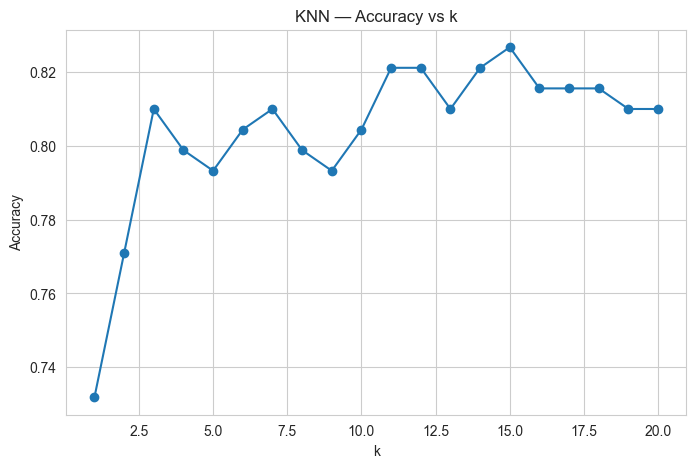

Best k: 15


In [67]:
#بهترین K
scores = []
for k in range(1, 21):
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train_sc, y_train)
    scores.append(m.score(X_test_sc, y_test))

plt.plot(range(1, 21), scores, marker="o")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("KNN — Accuracy vs k")
plt.show()

print("Best k:", scores.index(max(scores)) + 1)

# Class 8 — Decision Tree

درخت تصمیم قابل تفسیرهست

In [69]:
from sklearn.tree import DecisionTreeClassifier
#overfit جلوگیری از
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)

pred_dt = tree.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_dt))
print()
print(classification_report(y_test, pred_dt))

Accuracy: 0.776536312849162

              precision    recall  f1-score   support

           0       0.79      0.86      0.83       110
           1       0.75      0.64      0.69        69

    accuracy                           0.78       179
   macro avg       0.77      0.75      0.76       179
weighted avg       0.77      0.78      0.77       179



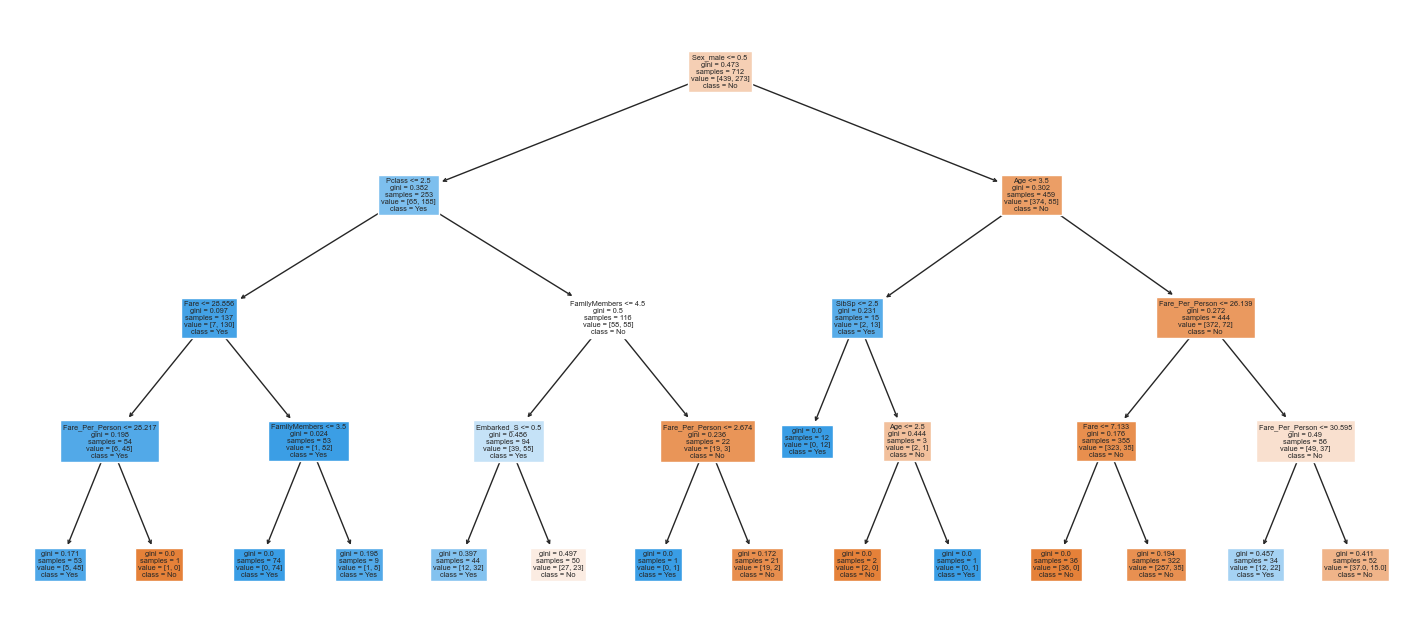

In [70]:
from sklearn.tree import plot_tree
#درخت تصمیم
plt.figure(figsize=(18, 8))
plot_tree(tree,
          feature_names=X.columns,
          class_names=["No", "Yes"],
          filled=True)
plt.show()

# Class 9 — Random Forest

چند درخت تصمیم رو با هم ترکیب می‌کنه و رای گیری می‌ کنه

In [72]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_rf))
print()
print(classification_report(y_test, pred_rf))

Accuracy: 0.8100558659217877

              precision    recall  f1-score   support

           0       0.84      0.85      0.85       110
           1       0.76      0.74      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



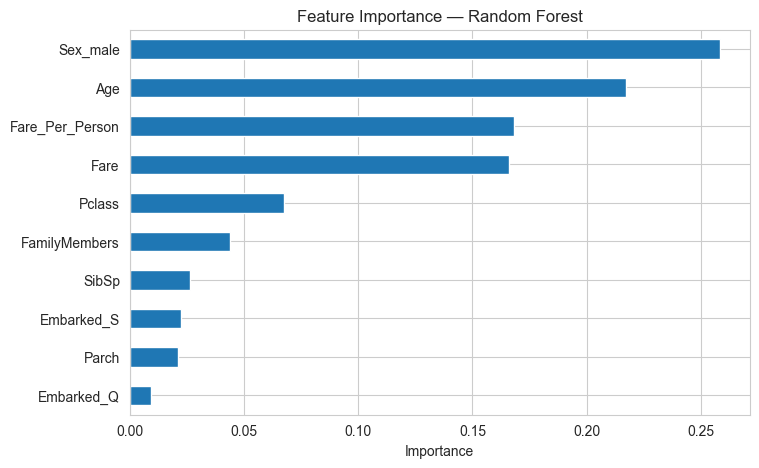

Sex_male           0.258315
Age                0.217150
Fare_Per_Person    0.168105
Fare               0.166005
Pclass             0.067356
FamilyMembers      0.043963
SibSp              0.026272
Embarked_S         0.022525
Parch              0.020958
Embarked_Q         0.009353
dtype: float64


In [73]:
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
#اهمیت هر ویژگی توی تصمیمگیری مدل
imp.plot(kind="barh")
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance")
plt.show()

print(imp.sort_values(ascending=False))

# Class 10 — Clustering

پیدا کردن گروه‌های طبیعی داده بدون استفاده از برچسب.

In [75]:
from sklearn.cluster import AgglomerativeClustering

X_sc = scaler.fit_transform(X)
#خوشه بندی سلسله مراتبی
agg = AgglomerativeClustering(n_clusters=3)
labels = agg.fit_predict(X_sc)

print("Cluster counts:", np.bincount(labels))

Cluster counts: [748  71  72]


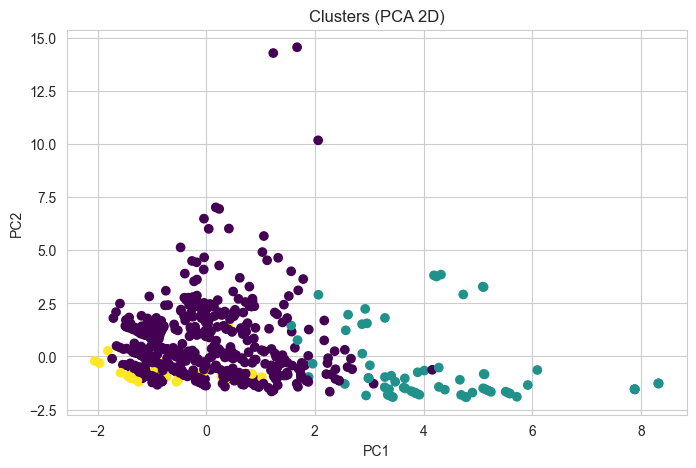

In [76]:
from sklearn.decomposition import PCA
#دیدن خوشه توی۲بعد با PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sc)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="viridis")
plt.title("Clusters (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

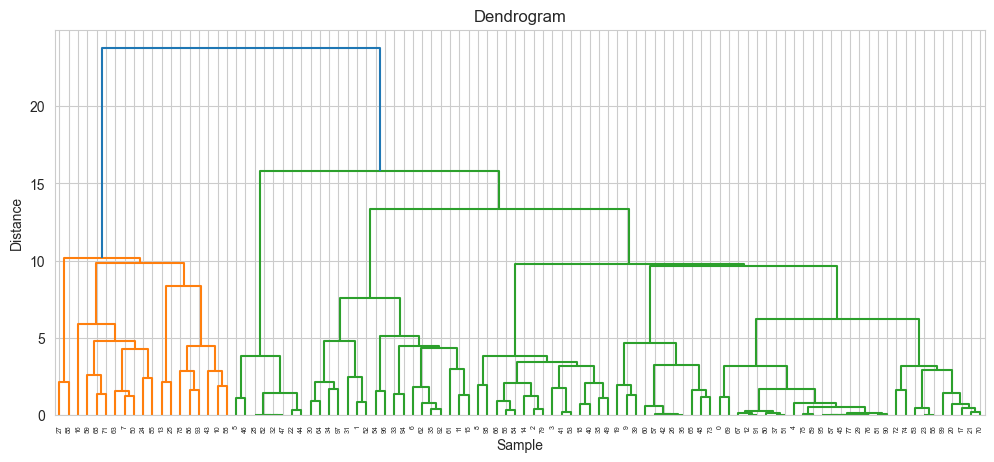

In [77]:
from scipy.cluster.hierarchy import dendrogram, linkage
#دیدن سلسله مراتبی خوشه ها
Z = linkage(X_sc[:100], method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z)
plt.title("Dendrogram")
plt.xlabel("Sample")
plt.ylabel("Distance")
plt.show()

In [78]:
# جدول مقایسه‌ی دقت مدل‌ها
results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_knn),
        accuracy_score(y_test, pred_dt),
        accuracy_score(y_test, pred_rf),
    ]
})

results = results.sort_values("Accuracy", ascending=False).reset_index(drop=True)
results

,Model,Accuracy
0,Random Forest,0.810056
1,Logistic Regression,0.798883
2,KNN,0.793296
3,Decision Tree,0.776536


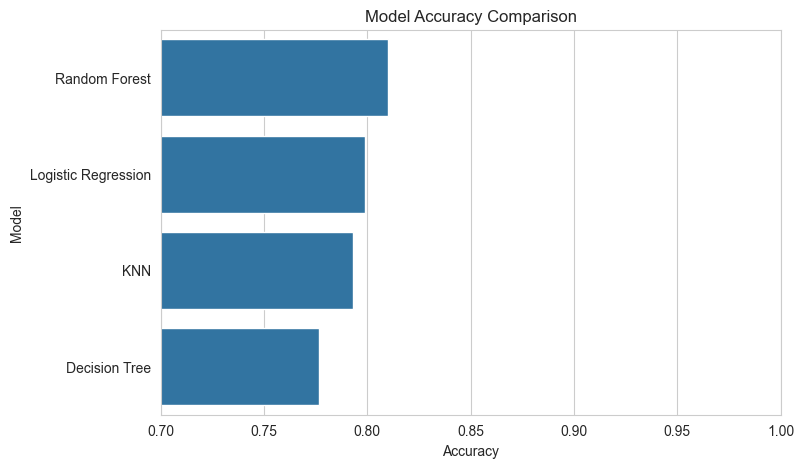

In [79]:
# نمودار مقایسه
sns.barplot(data=results, x="Accuracy", y="Model")
plt.title("Model Accuracy Comparison")
plt.xlim(0.7, 1.0)
plt.show()

# نتیجه‌گیری:
روی این دیتاست لیبل دار (طبقه بندی)
جنگل تصادفی بهترین نتیجه رو داد چون چندتا درخت رو با
همدیگه ترکیب میکنه و رای‌ گیری میکنه و پیشپردازش کمتری داره
و من ستون کابین رو حذف کردم چون هفتاد درصد خالی داشت
مهمترین ویژگی ها جنسیت، سن، هزینه بلیط بودن و زن ها شانس بیشتری برای زنده موندن داشتن